In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import pm4py
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import holidays
from enrichment import *
from feature_engineering import *
import importlib
import utils
importlib.reload(utils)
from utils import get_column_groups, get_ablation_variants, run_ablation
import importlib
import prefix_extraction
importlib.reload(prefix_extraction)
from prefix_extraction import extract_prefixes_fixed_length, extract_prefixes_with_time_cutoff


# Data Exploration and Preparation

In [ ]:
event_log = pm4py.read_xes("data/BPI Challenge 2017.xes")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [ ]:
display(event_log)
print(event_log.shape[0])
print(event_log["case:concept:name"].nunique())

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144


1202267
31509


In [ ]:
# # Filter for Application events
# event_log = event_log[event_log["EventOrigin"] == "Application"]
# event_log.reset_index()
# print(event_log.shape[0])
# print(event_log["case:concept:name"].nunique())


In [ ]:
event_log.reset_index()
display(event_log)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144


In [ ]:
event_log.info()
print(event_log["case:concept:name"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1202267 entries, 0 to 1202266
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype              
---  ------                 --------------    -----              
 0   Action                 1202267 non-null  object             
 1   org:resource           1202267 non-null  object             
 2   concept:name           1202267 non-null  object             
 3   EventOrigin            1202267 non-null  object             
 4   EventID                1202267 non-null  object             
 5   lifecycle:transition   1202267 non-null  object             
 6   time:timestamp         1202267 non-null  datetime64[ns, UTC]
 7   case:LoanGoal          1202267 non-null  object             
 8   case:ApplicationType   1202267 non-null  object             
 9   case:concept:name      1202267 non-null  object             
 10  case:RequestedAmount   1202267 non-null  float64            
 11  FirstWithdrawalAmount  4

# Event Log Enrichment

In [ ]:
# Define main column names
case_id_col = "case:concept:name"
activity_col = "concept:name"
timestamp_col = "time:timestamp"

In [ ]:
event_log = remove_empty_columns(event_log)
event_log = add_inter_event_time(event_log)
event_log = event_add_relative_case_time(event_log)
event_log = event_add_relative_log_time(event_log)

In [ ]:
display(event_log)
print(event_log["case:concept:name"].nunique())

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,...,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,time_since_prev,relative_case_time,relative_log_time
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1202262,Deleted,User_1,W_Call after offers,Workflow,Workitem_1817549786,ate_abort,2017-01-06 06:33:02.212000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,5,370
1202263,Created,User_1,W_Call after offers,Workflow,Workitem_363876066,schedule,2017-01-06 06:33:02.221000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,5,370
1202264,statechange,User_28,A_Cancelled,Application,ApplState_1869071797,complete,2017-01-16 09:51:21.114000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,15,381
1202265,statechange,User_28,O_Cancelled,Offer,OfferState_420066181,complete,2017-01-16 09:51:21.139000+00:00,Home improvement,New credit,Application_1350494635,...,NaN,NaN,NaN,NaN,NaN,NaN,Offer_1580299144,0.0,15,381


31509


In [ ]:
case_timestamps = event_log.groupby("case:concept:name")["time:timestamp"]
case_durations = case_timestamps.max() - case_timestamps.min()
avg_case_duration = case_durations.mean()
max_case_duration = case_durations.max()
min_case_duration = case_durations.min()
display(max_case_duration)
display(min_case_duration)
display(case_durations)
display(avg_case_duration)


Timedelta('286 days 01:44:18.654000')

Timedelta('0 days 00:03:21.062000')

case:concept:name
Application_1000086665   32 days 14:03:15.220000
Application_1000158214    8 days 00:47:34.438000
Application_1000311556   30 days 14:04:11.288000
Application_1000334415   13 days 15:06:16.631000
Application_1000339879   12 days 20:14:38.441000
                                   ...          
Application_999507989     6 days 07:14:35.738000
Application_999544538    79 days 18:48:35.307000
Application_999632431    31 days 18:35:34.310000
Application_999993467    13 days 18:42:42.772000
Application_999993812    17 days 16:27:25.962000
Name: time:timestamp, Length: 31509, dtype: timedelta64[ns]

Timedelta('21 days 21:35:25.923069948')

# Prefix Extraction

In [ ]:
# def extract_prefixes_with_time_cutoff(event_log, cutoff_in_days, target, holidays):
#     all_prefixes = []
#     static_attributes, dynamic_attributes = detect_static_attributes(event_log)
#     exclude = {"time:timestamp", "relative_case_time", "relative_log_time", "time_since_prev"}
#     static_attributes = [a for a in static_attributes if a not in exclude]
#     dynamic_attributes = [a for a in dynamic_attributes if a not in exclude]
#     reference_date = event_log["time:timestamp"].min()
#     activities_to_flag = event_log["concept:name"].unique()
#     for case, group in event_log.groupby("case:concept:name"):
#         features = {}
#         prefix = group[group["relative_case_time"] < cutoff_in_days]
#         prefix_start_time = group.iloc[0]["time:timestamp"]
#         prefix_end_time = group.iloc[-1]["time:timestamp"]
#         if group["relative_case_time"].max() < cutoff_in_days:
#             continue
#         A_pending_events = group[group["concept:name"] == "A_Pending"]
#         if len(A_pending_events) == 0:
#             continue
#         A_Pending_absolute_time = A_pending_events.iloc[0]["relative_log_time"]
#         add_case_attributes(prefix, features, static_attributes)
#         add_event_attributes(prefix, features, dynamic_attributes)
#         add_time_features(prefix, features)
#         # add_attributes_from_last_event(prefix, features)
#         add_activity_counts(prefix, features, activities_to_flag, activity_col)
#         # add_activity_flags(prefix, features, activities_to_flag)
#         add_activity_start_times(prefix, features, reference_date, activities_to_flag, activity_col, timestamp_col)
#         add_time_based_features(prefix, features, prefix_start_time, timestamp_col)
#         add_prefix_stats(prefix, features, case)
#         # add_numeric_aggregates(prefix, features)
#         add_resource_features(prefix, features)
#         # add_days_since_reference(prefix, features, reference_date)
#         add_holiday_features(prefix, features, prefix_end_time, holidays, timestamp_col, "UTC")
#         # activity_pairs = [("Send Fine", "Add penalty", "fine_to_penalty")]
#         # add_pairwise_delays(prefix, features, activity_pairs)
#         features["target"] = A_Pending_absolute_time
#         all_prefixes.append(features)
#     return all_prefixes

     
        
    


In [ ]:
nl_holidays = holidays.NL(years=2016)
for h in nl_holidays.items():
    print(h)


(datetime.date(2016, 1, 1), 'Nieuwjaarsdag')
(datetime.date(2016, 3, 25), 'Goede Vrijdag')
(datetime.date(2016, 3, 27), 'Eerste paasdag')
(datetime.date(2016, 3, 28), 'Tweede paasdag')
(datetime.date(2016, 4, 27), 'Koningsdag')
(datetime.date(2016, 5, 5), 'Hemelvaartsdag')
(datetime.date(2016, 5, 15), 'Eerste Pinksterdag')
(datetime.date(2016, 5, 16), 'Tweede Pinksterdag')
(datetime.date(2016, 12, 25), 'Eerste Kerstdag')
(datetime.date(2016, 12, 26), 'Tweede Kerstdag')


In [ ]:
print(event_log["case:concept:name"].nunique())

31509


### Train/Test Split

In [ ]:
case_ids = event_log[case_id_col].unique()

train_cases, test_cases = train_test_split(
    case_ids, 
    test_size=0.2, 
    random_state=42
)

### Prefix Extraction with Time Cutoff

In [ ]:
prefix_log_cutoff = extract_prefixes_with_time_cutoff(
    event_log,
    cutoff_in_days=5,
    target_activity='A_Pending',
    holidays=nl_holidays,
    timezone='Europe/Amsterdam'
)

In [ ]:
display([col for col in prefix_log_cutoff.columns if col.startswith("meta::")])

['meta::case_id', 'meta::prefix_length']

In [ ]:
prefix_log_cutoff_train = prefix_log_cutoff[prefix_log_cutoff['meta::case_id'].isin(train_cases)]
prefix_log_cutoff_test = prefix_log_cutoff[prefix_log_cutoff['meta::case_id'].isin(test_cases)]

### Prefix Extraction with Fixed Prefix Length

In [ ]:
prefix_log_fixed = extract_prefixes_fixed_length(
    event_log,
    prefix_length=5,
    target_activity='A_Pending',
    holidays=nl_holidays,
    timezone='Europe/Amsterdam'
)

In [ ]:
prefix_log_fixed_train = prefix_log_fixed[prefix_log_fixed['meta::case_id'].isin(train_cases)]
prefix_log_fixed_test = prefix_log_fixed[prefix_log_fixed['meta::case_id'].isin(test_cases)]

### Determine Prefix Extraction Variant To Analyze

In [ ]:
is_cutoff = True

if is_cutoff:
    prefix_log_train = prefix_log_cutoff_train
    prefix_log_test = prefix_log_cutoff_test
else:
    prefix_log_train = prefix_log_fixed_train
    prefix_log_test = prefix_log_fixed_test

In [ ]:
display(prefix_log_train)

,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,time::case_start_year,meta::case_id,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday,target
0,Home improvement,New credit,Application_1000158214,12500.0,Released,User_32,W_Call after offers,Workflow,Workitem_1002498045,suspend,...,2016,Application_1000158214,16,0.187500,3.0,2,0,198,25,161
3,Car,New credit,Application_1000386745,5000.0,Created,User_1,W_Call after offers,Workflow,Workitem_1499885168,schedule,...,2016,Application_1000386745,17,0.176471,3.0,2,0,19,204,340
4,"Other, see explanation",New credit,Application_1000474975,50000.0,Released,User_23,W_Call after offers,Workflow,Workitem_647381637,suspend,...,2016,Application_1000474975,15,0.266667,4.0,2,0,179,44,180
5,Home improvement,New credit,Application_1000557783,10000.0,Released,User_3,W_Call after offers,Workflow,Workitem_42779884,suspend,...,2016,Application_1000557783,15,0.266667,4.0,2,0,3,81,81
6,Car,New credit,Application_1000671285,5000.0,Released,User_32,W_Call after offers,Workflow,Workitem_201200016,suspend,...,2016,Application_1000671285,23,0.130435,3.0,3,0,5,25,111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16877,Existing loan takeover,New credit,Application_999487618,20000.0,Released,User_37,W_Call after offers,Workflow,Workitem_1632661508,suspend,...,2016,Application_999487618,18,0.222222,4.0,3,0,118,105,241
16878,Not speficied,New credit,Application_999507989,24000.0,Released,User_31,W_Call after offers,Workflow,Workitem_904055450,suspend,...,2016,Application_999507989,19,0.157895,3.0,4,0,2,82,82
16879,Car,New credit,Application_999544538,50000.0,Released,User_16,W_Call after offers,Workflow,Workitem_155345193,suspend,...,2016,Application_999544538,23,0.130435,3.0,5,2,152,71,206
16880,Home improvement,Limit raise,Application_999993467,10000.0,statechange,User_15,O_Sent (mail and online),Offer,OfferState_474648362,complete,...,2016,Application_999993467,18,0.055556,1.0,3,0,159,64,200


# Feature Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

feature_cols = [col for col in prefix_log_train.columns 
                if col not in ['meta::case_id', 'target', 'case_id']]

X_train = prefix_log_train[feature_cols].copy()
y_train = prefix_log_train['target']
X_test = prefix_log_test[feature_cols].copy()
y_test = prefix_log_test['target']

# Detect and label encode categorical columns
categorical_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(pd.concat([X_train[col], X_test[col]]).astype(str))
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# Convert everything to numeric and fill NaN with training medians
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')
train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f"Feature matrix shape: {X_train.shape}")
display(X_train.head())

Feature matrix shape: (13485, 119)


,case::case:LoanGoal,case::case:ApplicationType,case::case:concept:name,case::case:RequestedAmount,event::Action_last,event::org:resource_last,event::concept:name_last,event::EventOrigin_last,event::EventID_last,event::lifecycle:transition_last,...,time::start_day_of_week,time::start_month,time::case_start_year,meta::prefix_length,time::avg_time_between_events,time::max_time_between_events,system::number_of_unique_resources,system::num_holidays_in_prefix,system::days_to_next_holiday,system::days_since_last_holiday
0,6,1,0,12500.0,2,63,11,2,581,3,...,3,6,2016,16,0.187500,3.0,2,0,198,25
3,2,1,3,5000.0,0,0,11,2,4768,2,...,4,11,2016,17,0.176471,3.0,2,0,19,204
4,9,1,4,50000.0,2,53,11,2,13938,3,...,3,6,2016,15,0.266667,4.0,2,0,179,44
5,6,1,5,10000.0,2,60,11,2,12104,3,...,2,3,2016,15,0.266667,4.0,2,0,3,81
6,2,1,6,5000.0,2,63,11,2,9128,3,...,2,4,2016,23,0.130435,3.0,3,0,5,25


In [ ]:
display([col for col in prefix_log_train.columns if col.startswith("meta::")])

['meta::case_id', 'meta::prefix_length']

In [ ]:
print(categorical_cols)
print(X_test.dtypes[X_test.dtypes == 'object'])

['case::case:LoanGoal', 'case::case:ApplicationType', 'case::case:concept:name', 'event::Action_last', 'event::org:resource_last', 'event::concept:name_last', 'event::EventOrigin_last', 'event::EventID_last', 'event::lifecycle:transition_last', 'event::Accepted_last', 'event::Selected_last', 'event::OfferID_last']
Series([], dtype: object)


In [ ]:
print(X_test.dtypes[X_test.dtypes == 'object'])

Series([], dtype: object)


In [ ]:
display(X_test)

# Model Building and Training

In [ ]:
from aix360.algorithms.rbm.features import FeatureBinarizer
from aix360.algorithms.rbm.linear_regression import LinearRuleRegression
from aix360.algorithms.rbm.logistic_regression import LogisticRuleRegression


fb = FeatureBinarizer(numThresh=9)
X_train_bin = fb.fit_transform(X_train)
X_test_bin = fb.transform(X_test)

glrm = LinearRuleRegression(lambda0=0.05, lambda1=0.01)
glrm.fit(X_train_bin, y_train, X_train)  # X_train passed as Xstd for numeric features
# glrm = LogisticRuleRegression(lambda0=0.05, lambda1=0.01)
# glrm.fit(X_train_bin, y_train, X_train)

# Predict and evaluate
y_pred_glrm = glrm.predict(X_test_bin, X_test)
mae = mean_absolute_error(y_test, y_pred_glrm)
print(f"MAE: {mae:.2f} days")

# Inspect the rules
print(glrm.explain())

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
model = RandomForestRegressor(random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
from sklearn.metrics import root_mean_squared_error


y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae} days")
print(f"Root Mean Squared Error: {rmse} days")
print(f"R² Score: {r2:.4f}")


Mean Absolute Error: 0.5245304680600529 days
Root Mean Squared Error: 3.2410148207006366 days
R² Score: 0.9990


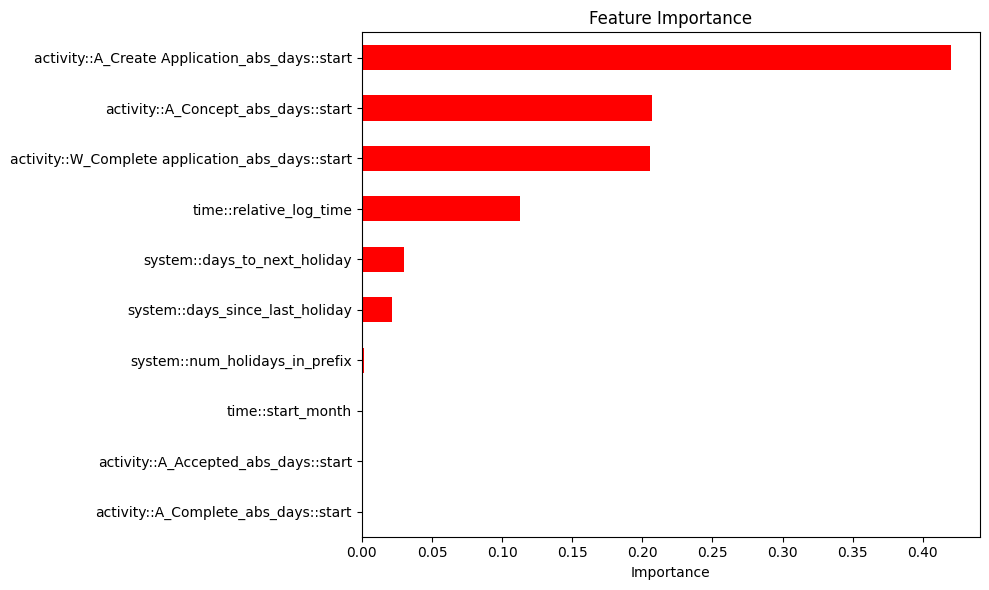

In [ ]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().tail(10).plot(kind='barh', figsize=(10, 6), color='r')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)

activity::A_Create Application_abs_days::start      0.419792
activity::A_Concept_abs_days::start                 0.207241
activity::W_Complete application_abs_days::start    0.205585
time::relative_log_time                             0.112762
system::days_to_next_holiday                        0.029897
system::days_since_last_holiday                     0.021573
system::num_holidays_in_prefix                      0.001710
time::start_month                                   0.001166
activity::A_Accepted_abs_days::start                0.000040
activity::A_Complete_abs_days::start                0.000040
dtype: float64

# Results

In [ ]:
high_level_variants, granular_variants = get_ablation_variants(X_train)

In [ ]:
bpic17_results_high = run_ablation(X_train, X_test, y_train, y_test, high_level_variants)

In [ ]:
bpic17_results_low = run_ablation(X_train, X_test, y_train, y_test, granular_variants)

In [ ]:
display(bpic17_results_high)

,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,87.145,102.776,-0.028,27
1,+ Case-level features,88.292,106.131,-0.096,31
2,+ Event-level features,7.629,10.726,0.989,115
3,+ System-level features,0.524,3.236,0.999,119
4,Full pipeline,0.525,3.241,0.999,119


In [ ]:
display(bpic17_results_high)
display(bpic17_results_low)

,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,87.145,102.776,-0.028,27
1,+ Case-level features,88.292,106.131,-0.096,31
2,+ Event-level features,7.629,10.726,0.989,115
3,+ System-level features,0.524,3.236,0.999,119
4,Full pipeline,0.525,3.241,0.999,119


,Variant,MAE,RMSE,R2,N Features
0,Raw sequence,87.145,102.776,-0.028,27
1,+ Case attributes,88.292,106.131,-0.096,31
2,+ Event aggregations,60.825,77.832,0.411,55
3,+ Activity start times,7.643,10.719,0.989,107
4,+ Temporal features,7.629,10.726,0.989,115
5,+ System features,0.524,3.236,0.999,119
6,Full pipeline,0.525,3.241,0.999,119


In [ ]:
plot_df = pd.DataFrame({
    'Actual (days)': y_test.values,
    'Predicted (days)': y_pred
})

reference_date = pd.Timestamp('2016-01-01', tz='UTC')
plot_df['Year'] = (reference_date + pd.to_timedelta(plot_df['Actual (days)'], unit='D')).dt.year.astype(str)

fig = px.scatter(
    plot_df,
    x='Actual (days)',
    y='Predicted (days)',
    color='Year',
    marginal_x='histogram',
    marginal_y='histogram',
    title='Actual vs Predicted Time to Loan Completion',
    opacity=0.6
)
fig.add_shape(
    type='line',
    x0=plot_df['Actual (days)'].min(),
    y0=plot_df['Actual (days)'].min(),
    x1=plot_df['Actual (days)'].max(),
    y1=plot_df['Actual (days)'].max(),
    line=dict(color='red', dash='dash', width=2)
)
fig.show()

In [ ]:
results_df = pd.DataFrame({
    'prefix_length': prefix_log_test['meta::prefix_length'].values,
    'actual': y_test.values,
    'predicted': y_pred
})

mae_by_prefix = results_df.groupby('prefix_length').apply(
    lambda g: mean_absolute_error(g['actual'], g['predicted'])
).reset_index()
mae_by_prefix.columns = ['Prefix Length', 'MAE (days)']

fig = px.line(
    mae_by_prefix,
    x='Prefix Length',
    y='MAE (days)',
    title='Average Prediction Error by Prefix Length',
    markers=True
)
fig.show()

/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_59563/361175548.py:7: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
print(prefix_log_test['meta::prefix_length'].describe())

count    3397.000000
mean       18.642920
std         4.858476
min         5.000000
25%        16.000000
50%        18.000000
75%        21.000000
max        94.000000
Name: meta::prefix_length, dtype: float64


In [ ]:
print(mae_by_prefix)

    Prefix Length  MAE (days)
0               5    0.820000
1               6    0.986667
2               7    0.466667
3               8    0.303600
4               9    0.564167
5              10    0.505385
6              11    6.618333
7              12    0.441250
8              13    0.387938
9              14    0.453333
10             15    0.681094
11             16    0.502391
12             17    0.711376
13             18    0.408842
14             19    0.447151
15             20    0.403826
16             21    0.443613
17             22    0.429708
18             23    0.398850
19             24    0.423580
20             25    0.432203
21             26    0.411800
22             27    0.424878
23             28    0.450500
24             29    0.412083
25             30    0.553684
26             31    0.486923
27             32    0.455000
28             33    0.466250
29             34    0.532500
30             35    0.594286
31             36    3.475000
32        

In [ ]:

# BPIC17
print(f"Actual range: {y_test.min()} - {y_test.max()}")
print(f"Predicted range: {y_pred.min():.1f} - {y_pred.max():.1f}")

Actual range: 10 - 396
Predicted range: 10.1 - 396.0


# Interpretation

In [ ]:
import plotly.express as px
A_pending_events = event_log[event_log["concept:name"] == "A_Pending"]
fig = px.histogram(A_pending_events, x="relative_case_time")
fig.add_vline(x=cutoff_in_days, line_width=3, line_dash="dash", line_color="red")
fig.show()